BMI = Body Mass Index; WC=Waist Circumference; Hip Circumference; WHR=Waist to Hip Ratio; FBS = Fasting Blood Sugar; RBS = Random Blood Sugar; TC=Total Cholesterol; TG=Triglyceride; HDL-C=High Density Lipoprotein-Cholesterol; LDL-C = Low Density Lipoprotein Cholesterol; VLDL C=Very Low-Density Lipoprotein-Cholesterol, PP2=Glucose Post Prandial

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 

In [2]:
import pandas as pd

sheet1_df = pd.read_excel(
    "C:/Users/HP/Desktop/competing risk project/Diabetes_risk_prediction_project/Data/DATA_diabetes.xlsx",
    sheet_name=0
)

sheet2_df = pd.read_excel(
    "C:/Users/HP/Desktop/competing risk project/Diabetes_risk_prediction_project/Data/DATA_diabetes.xlsx",
    sheet_name=1
)

In [3]:
import sqlite3

conn = sqlite3.connect("../Data/diabetes_project.db")
DATA = pd.read_sql("SELECT * FROM Diabetes_data", conn)

In [4]:
Df=pd.concat([sheet1_df,sheet2_df],ignore_index=True)

In [5]:
Df.to_sql(
    "Diabetes_data",
    conn,
    if_exists="replace",
    index=False
)

1329

In [6]:
Df.shape

(1329, 24)

In [7]:
Df.sample(15)

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],RBS [70-140 mg/dl],FBS [74-110 mg/dl],HEIGHT [CM],WEIGHT,WAIST CIRCUMFERENCE,...,PHYSICAL ACTIVITY,ALCOHOL,SMOKING,SERUM TRIGLYCERIDE [<150 mg/dl],SERUM CHOLESTEROL [<200 mg/dl],HDL CHOLESTEROL[200 mg/dl],LDL CHOLESTEROL [<100 mg/dl],VLDL CHOLESTEROL [12-32 mg/dl],CHOL/HDL,LDL/HDL
197,46,MALE,CONTROL,6.5,140,108,111,165.10,65,38,...,MODERATE,NEVER,NEVER,147,183,77,83,35,1.66,0.35
487,48,MALE,CONTROL,4.7,104,114,99,157.48,48,30,...,MODERATE,NEVER,NEVER,127,170,61,84,25,2.79,1.38
81,60,MALE,CONTROL,5.8,89,96,101,165.10,69,34,...,LOW,NEVER,NEVER,92,102,49,35,18,2.08,0.71
822,73,MALE,DIABETIC,5.8,245,116,224,157.48,50,34,...,LOW,LOW,NEVER,131,216,101,89,26,2.14,0.88
215,55,FEMALE,CONTROL,5.8,132,143,101,155.62,58,33,...,MODERATE,NEVER,NEVER,95,145,51,82,24,3.13,1.75
548,55,FEMALE,CONTROL,5.8,136,77,102,157.48,50,34,...,MODERATE,NEVER,NEVER,164,51,3,16,34,4.06,2.24
502,52,FEMALE,CONTROL,5.7,122,133,108,167.64,55,32,...,MODERATE,NEVER,NEVER,199,165,30,95,40,5.50,3.17
1039,45,FEMALE,DIABETIC,6.2,237,241,129,157.48,50,34,...,LOW,NEVER,NEVER,170,169,72,64,35,2.74,1.06
1104,65,MALE,DIABETIC,6.1,81,99,88,162.56,78,36,...,LOW,NEVER,NEVER,216,187,68,78,45,4.25,2.48
706,55,MALE,DIABETIC,5.2,111,147,207,180.34,55,32,...,LOW,NEVER,NEVER,188,178,63,77,38,2.83,1.22


In [8]:
Df.columns

Index(['AGE ', 'GENDER', 'SUBJECT TYPE', 'HBA1C', 'PP2 [<140 mg/dl]',
       'RBS [70-140 mg/dl]', 'FBS [74-110 mg/dl]', 'HEIGHT [CM]', 'WEIGHT',
       'WAIST CIRCUMFERENCE', 'HIP CIRCUMFERENCE', 'BMI', 'WAIST TO HIP RATIO',
       'TOBACCO', 'PHYSICAL ACTIVITY', 'ALCOHOL ', 'SMOKING',
       'SERUM TRIGLYCERIDE [<150 mg/dl]', 'SERUM CHOLESTEROL [<200 mg/dl]',
       'HDL CHOLESTEROL[200 mg/dl]', 'LDL CHOLESTEROL [<100 mg/dl]',
       'VLDL CHOLESTEROL [12-32 mg/dl]', 'CHOL/HDL', 'LDL/HDL'],
      dtype='object')

Dropping Columns like Waist Circumference and Hip Circumference to reduce multicollinearity ,
Rbs is just random blood sugar doesnt have much effect on the Diabetes predictions ,
Height and Weight also for the same reason due to multicollinearity with bmi ,
VLDL LDL are least important ,
Total Cholestrol as Serum Cholestrol is also least effective as we already have TG 

In [9]:
drop_col=['HIP CIRCUMFERENCE','WAIST CIRCUMFERENCE', 'RBS [70-140 mg/dl]','SMOKING','SERUM CHOLESTEROL [<200 mg/dl]','VLDL CHOLESTEROL [12-32 mg/dl]','HEIGHT [CM]', 'WEIGHT','LDL CHOLESTEROL [<100 mg/dl]']
drop_col

['HIP CIRCUMFERENCE',
 'WAIST CIRCUMFERENCE',
 'RBS [70-140 mg/dl]',
 'SMOKING',
 'SERUM CHOLESTEROL [<200 mg/dl]',
 'VLDL CHOLESTEROL [12-32 mg/dl]',
 'HEIGHT [CM]',
 'WEIGHT',
 'LDL CHOLESTEROL [<100 mg/dl]']

In [10]:
Data=DATA.drop(drop_col,axis=1)

In [11]:
Data.isnull().sum() 

AGE                                0
GENDER                             0
SUBJECT TYPE                       0
HBA1C                              0
PP2 [<140 mg/dl]                   0
FBS [74-110 mg/dl]                 0
BMI                                0
WAIST TO HIP RATIO                 0
TOBACCO                            0
PHYSICAL ACTIVITY                  0
ALCOHOL                            0
SERUM TRIGLYCERIDE [<150 mg/dl]    0
HDL CHOLESTEROL[200 mg/dl]         0
CHOL/HDL                           0
LDL/HDL                            0
dtype: int64

In [12]:
Data.dropna(inplace=True)

In [13]:
Data.isnull().sum()

AGE                                0
GENDER                             0
SUBJECT TYPE                       0
HBA1C                              0
PP2 [<140 mg/dl]                   0
FBS [74-110 mg/dl]                 0
BMI                                0
WAIST TO HIP RATIO                 0
TOBACCO                            0
PHYSICAL ACTIVITY                  0
ALCOHOL                            0
SERUM TRIGLYCERIDE [<150 mg/dl]    0
HDL CHOLESTEROL[200 mg/dl]         0
CHOL/HDL                           0
LDL/HDL                            0
dtype: int64

In [14]:
Data.shape

(629, 15)

In [15]:
Data['SUBJECT TYPE'].value_counts()

SUBJECT TYPE
CONTROL    629
Name: count, dtype: int64

In [16]:
Data['SUBJECT TYPE']=Data['SUBJECT TYPE'].map({
    'DIABETIC':1,
    'CONTROL':0
})

In [17]:
Data.columns=Data.columns.str.strip()

WE HAVE CODED THE DIABETIC PATIENTS AS 1 AND NON DIABETIC(CONTROL) AS 0

In [18]:
target_col=Data['SUBJECT TYPE']

In [19]:
num_col= Data.select_dtypes(exclude=['bool','object']).columns

In [20]:
num_col

Index(['AGE', 'SUBJECT TYPE', 'HBA1C', 'PP2 [<140 mg/dl]',
       'FBS [74-110 mg/dl]', 'BMI', 'WAIST TO HIP RATIO',
       'SERUM TRIGLYCERIDE [<150 mg/dl]', 'HDL CHOLESTEROL[200 mg/dl]',
       'CHOL/HDL', 'LDL/HDL'],
      dtype='object')

In [21]:
num_col=num_col.drop('SUBJECT TYPE')

In [22]:
cat_col=Data.select_dtypes(exclude=['int64','Float64']).columns.to_list()

In [23]:
cat_col

['GENDER', 'TOBACCO', 'PHYSICAL ACTIVITY', 'ALCOHOL']

In [24]:
num_col

Index(['AGE', 'HBA1C', 'PP2 [<140 mg/dl]', 'FBS [74-110 mg/dl]', 'BMI',
       'WAIST TO HIP RATIO', 'SERUM TRIGLYCERIDE [<150 mg/dl]',
       'HDL CHOLESTEROL[200 mg/dl]', 'CHOL/HDL', 'LDL/HDL'],
      dtype='object')

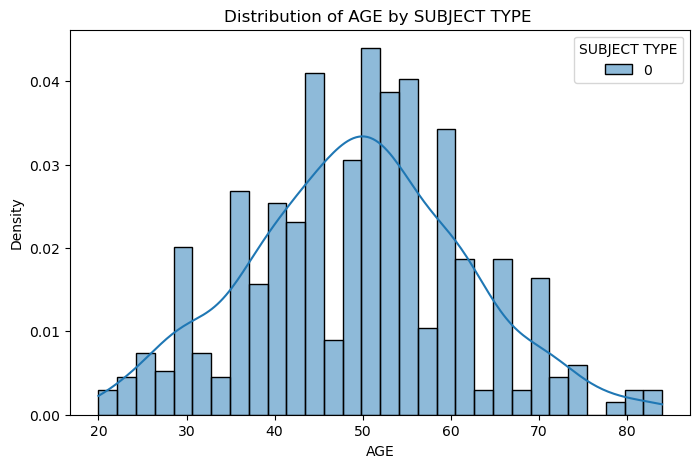

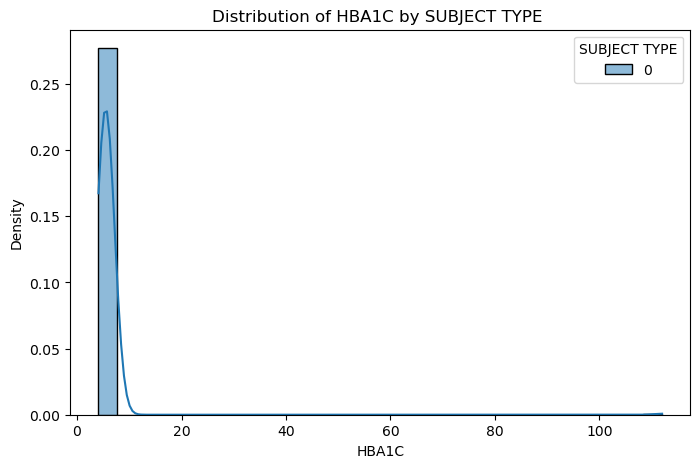

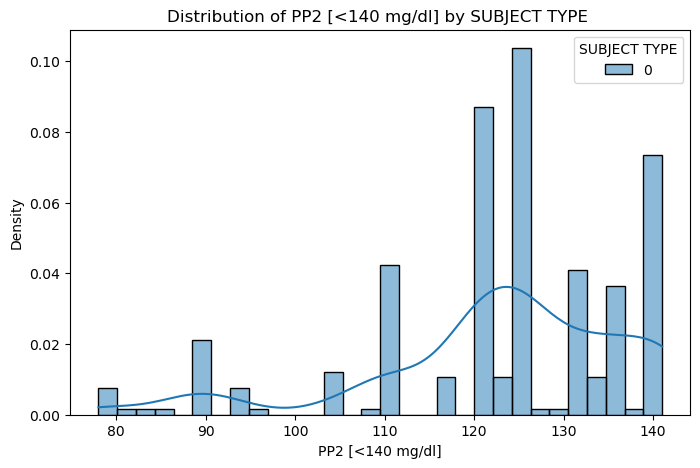

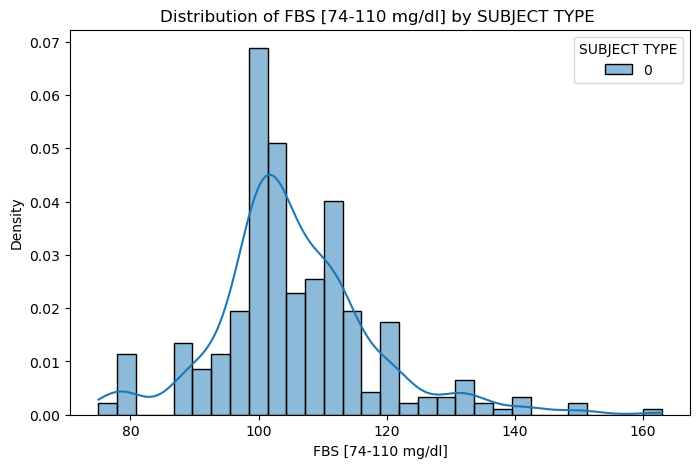

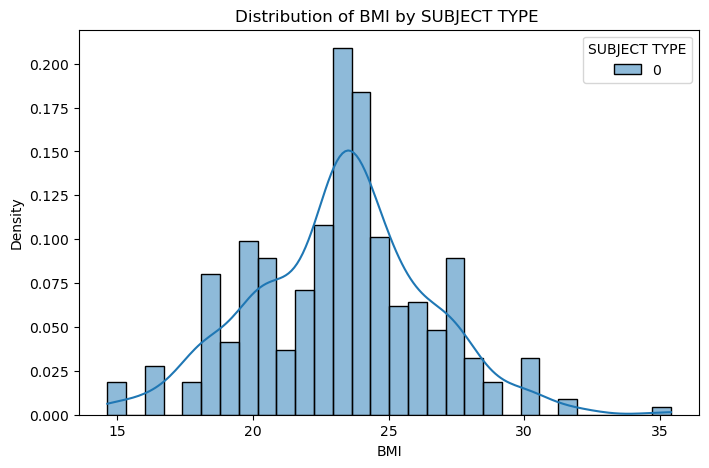

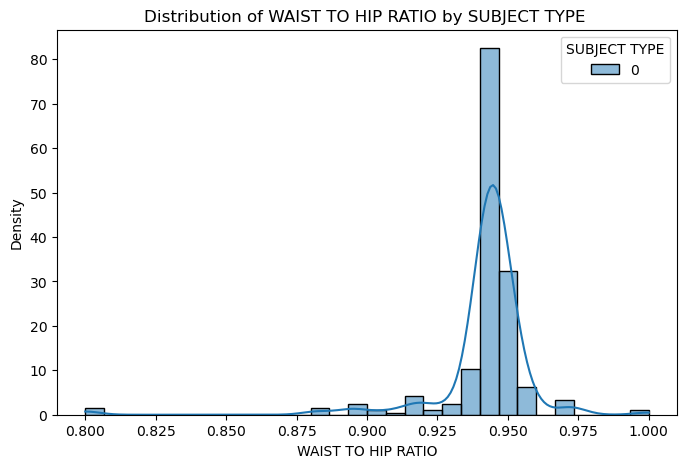

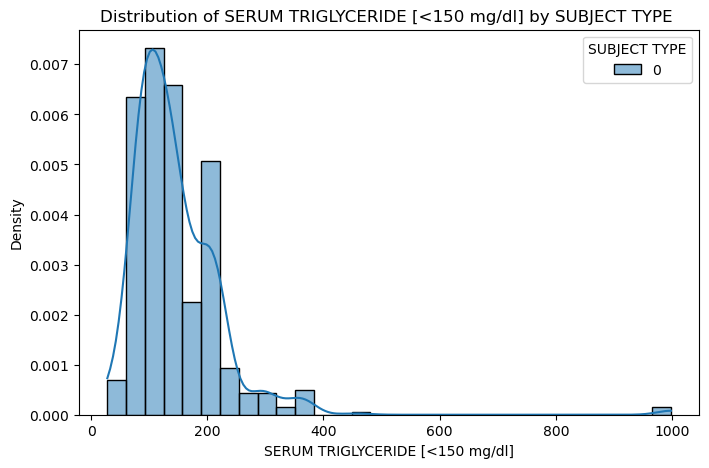

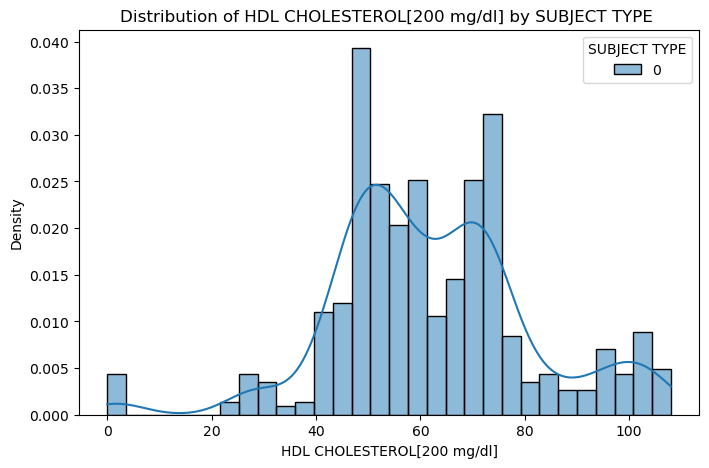

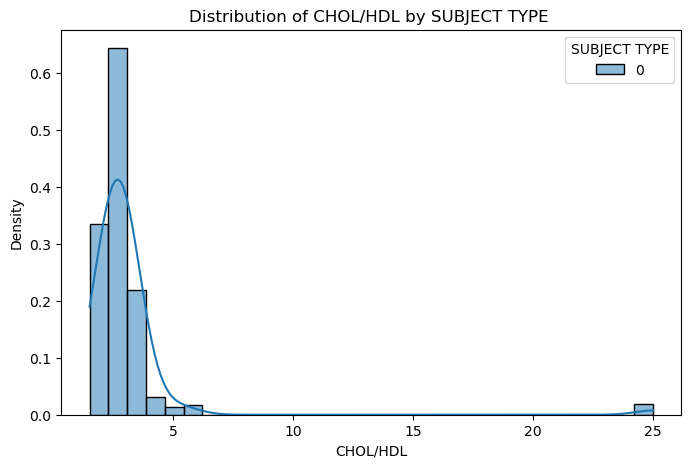

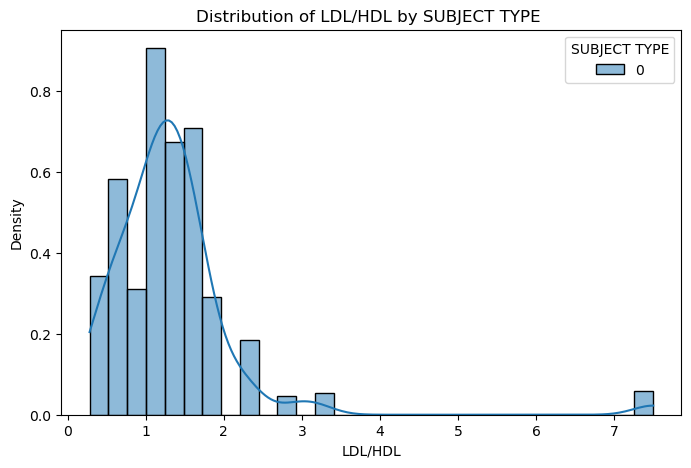

In [25]:
for col in num_col:
    plt.figure(figsize=(8,5))
    sns.histplot(x=col,
                 data=Data,
                 hue=target_col,
                 kde=True,
                 bins=30,
                 stat='density')
    plt.title(f'Distribution of {col} by SUBJECT TYPE ')
    plt.show()

Categorization of continuous metabolic variables was guided by a combination of observed distributional shifts between subject groups and established clinical thresholds, ensuring both statistical interpretability and clinical relevance.

Body Mass Index (BMI) was categorized into underweight (<18.5 kg/m²), normal (18.5–22.9 kg/m²), overweight at-risk (23.0–24.9 kg/m²), and obese (≥25.0 kg/m²) based on Asian-specific clinical guidelines. The BMI distribution shows a rightward shift among diabetic subjects, with higher density observed in the overweight and obese categories, supporting the role of increased adiposity and insulin resistance in the development of Type-2 Diabetes Mellitus.

The histogram of post-prandial glucose (PP2) stratified by subject type shows a clear rightward shift in diabetic individuals with minimal overlap below 140 mg/dl and dominant density above 200 mg/dl. Accordingly, PP2 was categorized into normal (≤140 mg/dl), impaired tolerance (140–200 mg/dl), and diabetic (>200 mg/dl) intervals, consistent with established clinical thresholds and observed distributional separation.

The fasting blood glucose distribution shows a pronounced rightward shift among diabetic subjects, with controls concentrated below 100 mg/dl and diabetics predominating above 126 mg/dl. Accordingly, fasting glucose was categorized into normal (<100 mg/dl), impaired fasting glucose (100–125 mg/dl), and diabetic (≥126 mg/dl) groups, consistent with established clinical thresholds and the observed distributional separation.

Serum triglyceride levels were categorized into three clinically meaningful groups: normal (<150 mg/dl), borderline (150–199 mg/dl), and high (≥200 mg/dl). The high category combined both high and very high triglyceride ranges to improve statistical stability and model interpretability while retaining clinical relevance for Type-2 diabetes risk assessment.

High-density lipoprotein (HDL) cholesterol levels were categorized into three clinically meaningful groups: low (<40 mg/dl), normal (40–59 mg/dl), and protective (≥60 mg/dl). This classification reflects the inverse association of HDL with cardiometabolic risk and is supported by the observed left-shifted distribution among diabetic subjects and higher HDL concentrations among controls.

Glycated hemoglobin (HbA1c) levels were categorized into three clinically meaningful groups: normal (<5.7%), prediabetic (5.7–6.4%), and diabetic (≥6.5%), in accordance with established diagnostic criteria. This categorization reflects long-term glycemic exposure and provides a stable indicator of Type-2 diabetes risk for statistical modeling and clinical interpretation.

The CHOL/HDL ratio was classified into low (<3.5), moderate (3.5–5.0), and high (>5.0) cardiovascular risk categories. The distribution reveals a pronounced right-skew among diabetic individuals, with a greater proportion falling into the moderate and high-risk categories, reflecting the characteristic dyslipidemia and reduced protective HDL levels associated with insulin resistance in Type-2 Diabetes.

The LDL/HDL ratio was categorized as optimal (<2.0), borderline (2.0–3.5), and high risk (>3.5). Diabetic subjects exhibit greater variability and higher representation in the borderline and high-risk categories, indicating an imbalance between atherogenic and protective lipoproteins, a metabolic alteration commonly observed in Type-2 Diabetes Mellitus.

Waist-to-hip ratio (WHR) was categorized into normal (<0.90), moderate abdominal obesity (0.90–0.99), and high central obesity (≥1.00) based on established clinical thresholds. Although the overall distribution shows substantial overlap between diabetic and non-diabetic subjects, diabetic individuals exhibit a modest rightward shift with greater representation in the higher WHR categories, reflecting increased visceral adiposity and its known role in insulin resistance and Type-2 Diabetes Mellitus.

In [26]:
Data['CHOL/HDL']=np.where(Data['CHOL/HDL']<=3.5,0,np.where((Data['CHOL/HDL']>3.5)&(Data['CHOL/HDL']<5.0),1,2))

In [27]:
Data['HDL CHOLESTEROL[200 mg/dl]']=np.where(Data['HDL CHOLESTEROL[200 mg/dl]']>=60,0,np.where((Data['HDL CHOLESTEROL[200 mg/dl]']>=40)&(Data['HDL CHOLESTEROL[200 mg/dl]']<=60),1,2))

In [28]:
Data['SERUM TRIGLYCERIDE [<150 mg/dl]']=np.where(Data['SERUM TRIGLYCERIDE [<150 mg/dl]']<=150,0,np.where((Data['SERUM TRIGLYCERIDE [<150 mg/dl]']>150)&(Data['SERUM TRIGLYCERIDE [<150 mg/dl]']<=200),1,2))

In [29]:
Data['FBS [74-110 mg/dl]']=np.where(Data['FBS [74-110 mg/dl]']<=100,0,np.where((Data['FBS [74-110 mg/dl]']>100)&(Data['FBS [74-110 mg/dl]']<=126),1,2))

In [30]:
Data['PP2 [<140 mg/dl]']=np.where(Data['PP2 [<140 mg/dl]']<=140,0,np.where((Data['PP2 [<140 mg/dl]']>140)&(Data['PP2 [<140 mg/dl]']<=200),1,2))

In [31]:
Data['HBA1C']=np.where(Data['HBA1C']<5.7,0,np.where((Data['HBA1C']>=5.7)&(Data['HBA1C']<=6.4),1,2))

In [32]:
Data['WAIST TO HIP RATIO']=np.where(Data['WAIST TO HIP RATIO']<0.90,0,np.where((Data['WAIST TO HIP RATIO']>=0.90)& (Data['WAIST TO HIP RATIO']<0.99),1,2))

In [33]:
Data['BMI']=np.where(Data['BMI']<=18.5,0,np.where((Data['BMI']>18.5)&(Data['BMI']<22.9),1,2))

In [34]:
Data['LDL/HDL']=np.where(Data['LDL/HDL']<=2.0,0,np.where((Data['LDL/HDL']>2.0)&(Data['LDL/HDL']<3.5),1,2))

In [35]:
Data['PP2 [<140 mg/dl]'].value_counts()

PP2 [<140 mg/dl]
0    540
1     89
Name: count, dtype: int64

In [36]:
Data['HBA1C'].value_counts()

HBA1C
0    445
1    155
2     29
Name: count, dtype: int64

In [37]:
Data.head(20)

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],FBS [74-110 mg/dl],BMI,WAIST TO HIP RATIO,TOBACCO,PHYSICAL ACTIVITY,ALCOHOL,SERUM TRIGLYCERIDE [<150 mg/dl],HDL CHOLESTEROL[200 mg/dl],CHOL/HDL,LDL/HDL
0,70,MALE,0,0,0,0,2,1,HIGH,LOW,LOW,0,0,0,0
1,60,FEMALE,0,0,0,1,2,1,NEVER,MODERATE,NEVER,0,0,0,0
2,60,FEMALE,0,0,0,1,2,1,NEVER,MODERATE,NEVER,0,0,0,0
3,43,MALE,0,0,0,1,2,1,NEVER,LOW,LOW,0,0,0,0
4,65,FEMALE,0,1,0,1,2,1,NEVER,MODERATE,NEVER,1,0,0,0
5,75,FEMALE,0,0,0,1,2,1,LOW,MODERATE,NEVER,0,1,0,0
6,57,MALE,0,1,1,0,2,1,MODERATE,LOW,LOW,0,0,0,0
7,70,MALE,0,0,0,0,2,1,MODERATE,LOW,LOW,0,0,0,0
8,48,FEMALE,0,0,0,1,2,1,NEVER,MODERATE,NEVER,2,1,1,1
9,29,FEMALE,0,0,0,1,1,1,NEVER,MODERATE,NEVER,2,0,0,0


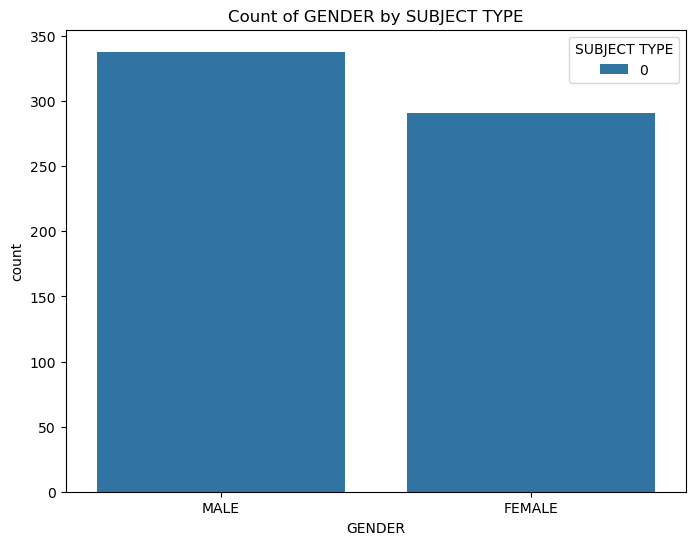

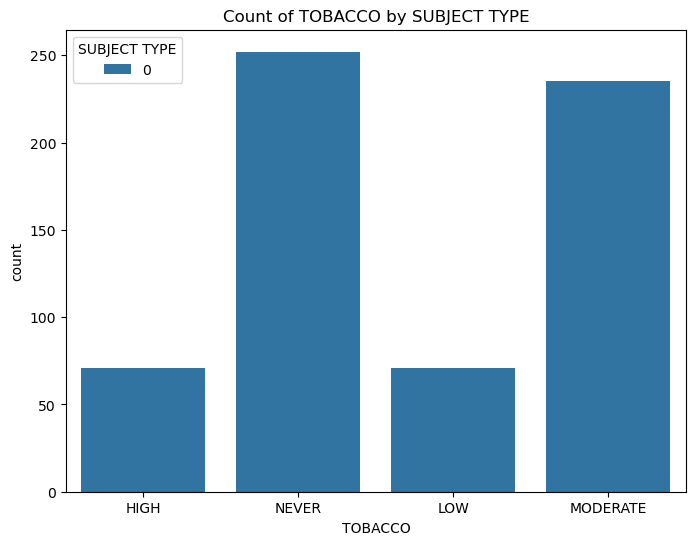

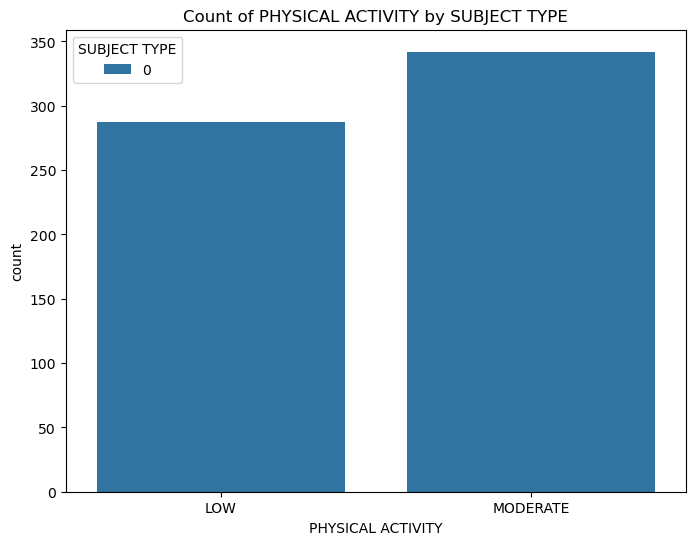

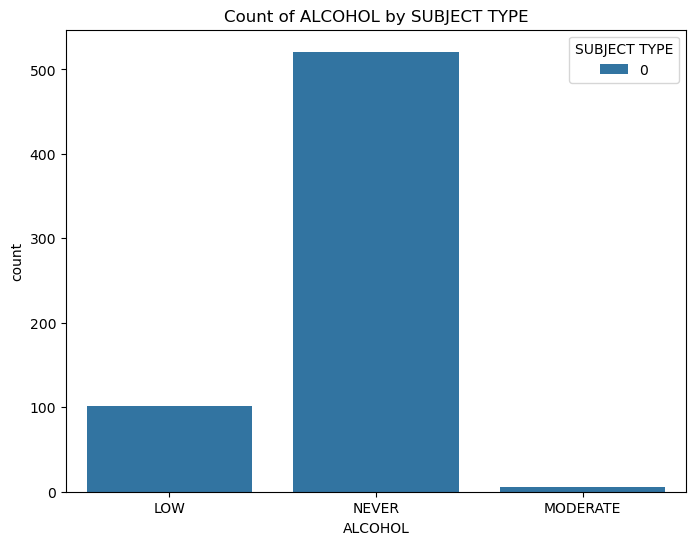

In [38]:
for col in cat_col:
    plt.figure(figsize=(8,6))
    sns.countplot(
        x=col,
        hue=target_col,
        data=Data,
        stat='count',
    )
    plt.title(f'Count of {col} by SUBJECT TYPE')
    plt.show()

In [39]:
Data['TOBACCO'].value_counts()

TOBACCO
NEVER       252
MODERATE    235
HIGH         71
LOW          71
Name: count, dtype: int64

In [40]:
Data.loc[Data['TOBACCO']=='LM']

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],FBS [74-110 mg/dl],BMI,WAIST TO HIP RATIO,TOBACCO,PHYSICAL ACTIVITY,ALCOHOL,SERUM TRIGLYCERIDE [<150 mg/dl],HDL CHOLESTEROL[200 mg/dl],CHOL/HDL,LDL/HDL


Dropped the 722th row for convenience in the model training as the Tobacco category was LIGHT MODERATE AND WAS THE ONLY ROW TO HAVE THAT 

In [42]:
Data['TOBACCO']=Data['TOBACCO'].map({
    'NEVER':0,
    'LOW':1,
    'MODERATE':2,
    'HIGH':3
})

In [43]:
Data['PHYSICAL ACTIVITY'].value_counts()

PHYSICAL ACTIVITY
MODERATE    342
LOW         287
Name: count, dtype: int64

In [44]:
Data['PHYSICAL ACTIVITY']=Data['PHYSICAL ACTIVITY'].map({
    'LOW':0,
    'MODERATE': 1
})

In [45]:
Data['PHYSICAL ACTIVITY'].value_counts()

PHYSICAL ACTIVITY
1    342
0    287
Name: count, dtype: int64

In [48]:
Data['ALCOHOL'].value_counts()

ALCOHOL
NEVER       521
LOW         102
MODERATE      6
Name: count, dtype: int64

In [60]:
Data['ALCOHOL']=Data['ALCOHOL'].map({
    'NEVER':0,
    'LOW':1,
    'MODERATE':2,
    'HIGH':3
})

In [51]:
Data['ALCOHOL'].value_counts()

ALCOHOL
NEVER       521
LOW         102
MODERATE      6
Name: count, dtype: int64

In [52]:
Data['GENDER'].value_counts()

GENDER
MALE      338
FEMALE    291
Name: count, dtype: int64

In [53]:
Data['GENDER']=Data['GENDER'].map({
    'MALE':0,
    'FEMALE':1
})

In [54]:
corr_df= pd.DataFrame(num_col)

In [55]:
num_col= Data.select_dtypes(exclude=['bool','object'])

In [56]:
# Gender
Data['GENDER'].value_counts(),

(GENDER
 0    338
 1    291
 Name: count, dtype: int64,)

In [57]:
Data['PHYSICAL ACTIVITY'].value_counts()

PHYSICAL ACTIVITY
1    342
0    287
Name: count, dtype: int64

In [59]:
Data['ALCOHOL'].value_counts()

ALCOHOL
NEVER       521
LOW         102
MODERATE      6
Name: count, dtype: int64

In [61]:
Data['TOBACCO'].value_counts()

TOBACCO
0    252
2    235
3     71
1     71
Name: count, dtype: int64

In [62]:
Data.head(20)

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],FBS [74-110 mg/dl],BMI,WAIST TO HIP RATIO,TOBACCO,PHYSICAL ACTIVITY,ALCOHOL,SERUM TRIGLYCERIDE [<150 mg/dl],HDL CHOLESTEROL[200 mg/dl],CHOL/HDL,LDL/HDL
0,70,0,0,0,0,0,2,1,3,0,1,0,0,0,0
1,60,1,0,0,0,1,2,1,0,1,0,0,0,0,0
2,60,1,0,0,0,1,2,1,0,1,0,0,0,0,0
3,43,0,0,0,0,1,2,1,0,0,1,0,0,0,0
4,65,1,0,1,0,1,2,1,0,1,0,1,0,0,0
5,75,1,0,0,0,1,2,1,1,1,0,0,1,0,0
6,57,0,0,1,1,0,2,1,2,0,1,0,0,0,0
7,70,0,0,0,0,0,2,1,2,0,1,0,0,0,0
8,48,1,0,0,0,1,2,1,0,1,0,2,1,1,1
9,29,1,0,0,0,1,1,1,0,1,0,2,0,0,0


In [63]:
Data.to_excel('coded_diabetes.xlsx',index=False)

In [69]:
from lifelines import CoxPHFitter
cox_ph=CoxPHFitter()
cox_ph.fit(
    Data,
    'AGE',
    'SUBJECT TYPE'
)
   
cox_ph.summary.to_csv('Result.csv',index=True)

ConvergenceError: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

In [ ]:
cox_ph.print_summary(decimals=3)

<lifelines.CoxPHFitter: fitted with 1312 total observations, 629 right-censored observations>
             duration col = 'AGE '
                event col = 'SUBJECT TYPE'
      baseline estimation = breslow
   number of observations = 1312
number of events observed = 683
   partial log-likelihood = -4037.895
         time fit was run = 2026-02-14 09:52:14 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                         
GENDER                           0.453     1.573     0.081           0.295           0.611               1.343               1.842
HBA1C                            0.167     1.182     0.046           0.077           0.258               1.080               1.294
PP2 [<140 mg/dl]                 0.191     1.210     0.053           0.088           0.294               1.092               1.342
FBS [74-110 mg/dl]               0.325     1.384     0.063           0.201           0.449               1.223               1.566
BMI                             -0.052     0.949     0.060          -0.170           0.065               0.844               1.067
WAIST TO HIP RATIO              -0.247     0.781     0.123          -0.488          -0.006               0.614               0.994
TOBACCO                         -0.129     0.879     0.047          -0.221          -0.038               0.802               0.963
PHYSICAL ACTIVITY               -0.643     0.526     0.114          -0.867          -0.420               0.420               0.657
ALCOHOL                          0.284     1.328     0.051           0.184           0.383               1.202               1.467
SERUM TRIGLYCERIDE [<150 mg/dl]  0.070     1.072     0.044          -0.016           0.156               0.984               1.169
HDL CHOLESTEROL[200 mg/dl]      -0.171     0.842     0.072          -0.313          -0.030               0.732               0.970
CHOL/HDL                         0.102     1.108     0.208          -0.306           0.510               0.736               1.666
LDL/HDL                         -0.092     0.912     0.208          -0.501           0.316               0.606               1.372

                                 cmp to      z       p  -log2(p)
covariate                                                       
GENDER                            0.000  5.618 <0.0005    25.629
HBA1C                             0.000  3.622 <0.0005    11.738
PP2 [<140 mg/dl]                  0.000  3.624 <0.0005    11.751
FBS [74-110 mg/dl]                0.000  5.140 <0.0005    21.797
BMI                               0.000 -0.875   0.382     1.390
WAIST TO HIP RATIO                0.000 -2.011   0.044     4.494
TOBACCO                           0.000 -2.765   0.006     7.455
PHYSICAL ACTIVITY                 0.000 -5.639 <0.0005    25.800
ALCOHOL                           0.000  5.583 <0.0005    25.334
SERUM TRIGLYCERIDE [<150 mg/dl]   0.000  1.594   0.111     3.173
HDL CHOLESTEROL[200 mg/dl]        0.000 -2.379   0.017     5.848
CHOL/HDL                          0.000  0.490   0.624     0.681
LDL/HDL                           0.000 -0.443   0.658     0.604
---
Concordance = 0.685
Partial AIC = 8101.791
log-likelihood ratio test = 278.013 on 13 df
-log2(p) of ll-ratio test = 169.501

: 

: 

: 

: 

In [68]:
cox_ph.check_assumptions(
    Data,
    p_value_threshold=0.05,
    show_plots=False
)

AttributeError: Must call `fit` first.

In [66]:
Data.head()

,AGE,GENDER,SUBJECT TYPE,HBA1C,PP2 [<140 mg/dl],FBS [74-110 mg/dl],BMI,WAIST TO HIP RATIO,TOBACCO,PHYSICAL ACTIVITY,ALCOHOL,SERUM TRIGLYCERIDE [<150 mg/dl],HDL CHOLESTEROL[200 mg/dl],CHOL/HDL,LDL/HDL
0,70,0,0,0,0,0,2,1,3,0,1,0,0,0,0
1,60,1,0,0,0,1,2,1,0,1,0,0,0,0,0
2,60,1,0,0,0,1,2,1,0,1,0,0,0,0,0
3,43,0,0,0,0,1,2,1,0,0,1,0,0,0,0
4,65,1,0,1,0,1,2,1,0,1,0,1,0,0,0
